# LoRA-based mBART50 Fine-tuning for Tagalog Dataset

Uncomment before running.

In [1]:
# !pip uninstall torch -y
# !pip install --pre torch==2.9.0.dev20250803+cu128 --index-url https://download.pytorch.org/whl/nightly/cu128
# !pip install transformers sacrebleu
#!pip install --upgrade peft  
# !pip install datasets
# !pip install --upgrade transformers accelerate

In [2]:
#!pip install tiktoken sentencepiece
#!pip install matplotlib
# !pip install evaluate

For saving the checkpoints

In [3]:
ckpts_path = "./ckpts"

In [4]:
import torch

def _check_gpu():
    if torch.cuda.is_available():
        print(f"GPU is available: {torch.cuda.get_device_name(0)}")
    else:
        print("GPU not available, using CPU.")
    return torch.cuda.is_available()

use_gpu = _check_gpu()

GPU is available: NVIDIA GeForce RTX 5070


In [5]:
torch.manual_seed(42)
if use_gpu:
    torch.cuda.manual_seed_all(42)

TOKENIZERS_PARALLELISM = False

# Data Preprocessing

In [11]:
from datasets import load_dataset, Dataset, DatasetDict, Value

# Define the data files
data_files = {
    "train": {
        "tl": "../corpus-parallel-txt/train.tl.cleaned",
        "en": "../corpus-parallel-txt/train.en.cleaned"
    },
    "validation": {
        "tl": "../corpus-parallel-txt/val.tl.cleaned",
        "en": "../corpus-parallel-txt/val.en.cleaned"
    },
    # "test": {
    #     "tl": "../corpus-parallel-txt/test.tl",
    #     "en": "../corpus-parallel-txt/test.en"
    # }
}

dataset_dict = DatasetDict()

for split_name in data_files:
    # Read source and target files
    with open(data_files[split_name]["tl"], "r", encoding="utf-8") as f_src:
        src_texts = [line.strip() for line in f_src.readlines()]
    
    with open(data_files[split_name]["en"], "r", encoding="utf-8") as f_tgt:
        tgt_texts = [line.strip() for line in f_tgt.readlines()]
    
    # Create dataset with parallel texts
    dataset_dict[split_name] = Dataset.from_dict({
        "tl": src_texts,
        "en": tgt_texts
    })

data = dataset_dict

In [12]:
data

DatasetDict({
    train: Dataset({
        features: ['tl', 'en'],
        num_rows: 7240
    })
    validation: Dataset({
        features: ['tl', 'en'],
        num_rows: 1810
    })
})

In [15]:
# get 1 record
data["validation"][525]

{'tl': 'hahaha ako to maganda kahit stressed at depressed',
 'en': '"Haha, that\'s me, beautiful even when stressed and depressed."'}

# Tokenization

In [9]:
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

SRC_LANG = "tl_XX"
TGT_LANG = "en_XX"

tokenizer = AutoTokenizer.from_pretrained("facebook/mbart-large-50-many-to-many-mmt", use_fast=False)
model = AutoModelForSeq2SeqLM.from_pretrained("facebook/mbart-large-50-many-to-many-mmt")

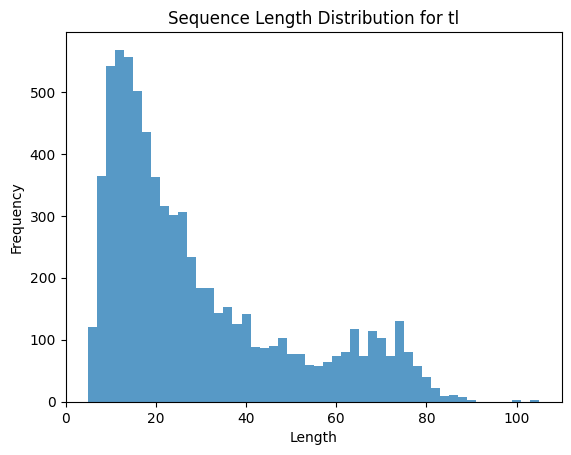

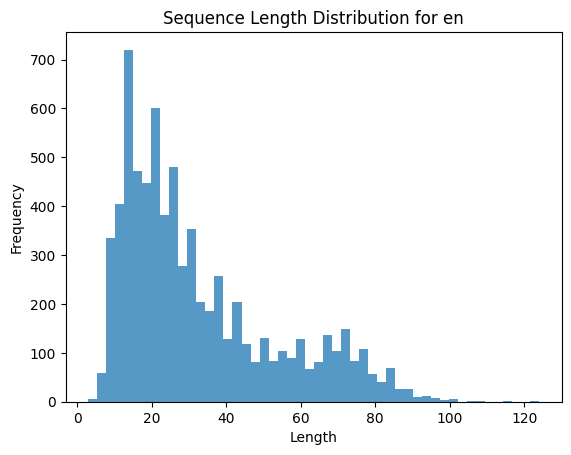

In [10]:
# Check max sequence length in the dataset
import matplotlib.pyplot as plt
import numpy as np

def plot_seq_length_distrib(data, language_key, tokenizer):
    lengths = [len(tokenizer.encode(example[language_key])) for example in data]
    plt.hist(lengths, bins=50, alpha=0.75)
    plt.title(f"Sequence Length Distribution for {language_key}")
    plt.xlabel("Length")
    plt.ylabel("Frequency")
    plt.show()
    return lengths

src_lengths = plot_seq_length_distrib(data["train"], "tl", tokenizer)
tgt_lengths = plot_seq_length_distrib(data["train"], "en", tokenizer)

In [10]:
def preprocess(examples):
    inputs = [ex for ex in examples["tl"]]
    targets = [ex for ex in examples["en"]]

    tokenizer.src_lang = SRC_LANG
    tokenizer.tgt_lang = TGT_LANG

    model_inputs = tokenizer(inputs, max_length=128, truncation=True, padding="max_length")

    # Setup the tokenizer for targets
    with tokenizer.as_target_tokenizer():
        labels = tokenizer(targets, max_length=128, truncation=True, padding="max_length")

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

In [16]:
train_ds = data["train"].map(preprocess, batched=True)
val_ds = data["validation"].map(preprocess, batched=True)
# test_ds = data["test"].map(preprocess, batched=True)

Map:   0%|          | 0/7240 [00:00<?, ? examples/s]c:\Users\Reejay Salinas\Downloads\SalinTala\Moodeng-MT\.venv\Lib\site-packages\transformers\tokenization_utils_base.py:4007: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(
Map: 100%|██████████| 1810/1810 [00:00<00:00, 17375.47 examples/s]


In [13]:
from peft import LoraConfig, get_peft_model

lora_config = LoraConfig(
    r=16,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj", "k_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="SEQ_2_SEQ_LM"
)

In [14]:
model_lora = get_peft_model(model, lora_config)

model_lora.print_trainable_parameters()

trainable params: 3,538,944 || all params: 614,418,432 || trainable%: 0.5760


In [15]:
from accelerate import Accelerator, DataLoaderConfiguration

dataloader_config = DataLoaderConfiguration(
    dispatch_batches=False,
    split_batches=True
)

accelerator = Accelerator(dataloader_config=dataloader_config)

In [16]:
from transformers import Seq2SeqTrainingArguments

training_args = Seq2SeqTrainingArguments(
    output_dir="./mbart-lora-finetuned",
    eval_strategy='epoch',
    learning_rate=3e-4,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    weight_decay=0.01,
    save_total_limit=3,
    save_steps=500,
    save_strategy="steps",
    num_train_epochs=5,
    predict_with_generate=True,
    fp16=True if use_gpu else False,
    logging_dir="./logs",
    logging_steps=10,
)

In [17]:
from transformers import Seq2SeqTrainer, DataCollatorForSeq2Seq

data_collator = DataCollatorForSeq2Seq(tokenizer, model=model_lora)

trainer = Seq2SeqTrainer(
    model=model_lora,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer,
    data_collator=data_collator,
)

C:\Users\Reejay Salinas\AppData\Local\Temp\ipykernel_6736\4213164329.py:5: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


# Training with LoRA

In [18]:
trainer.train()
#trainer.train(resume_from_checkpoint=ckpts_path if ckpts_path else None)

Epoch,Training Loss,Validation Loss
1,8.079500,8.172986
2,7.790700,8.116783
3,8.213600,8.085867
4,8.079300,8.069597
5,8.225900,8.063282


TrainOutput(global_step=4525, training_loss=8.239084179282846, metrics={'train_runtime': 746.7709, 'train_samples_per_second': 48.475, 'train_steps_per_second': 6.059, 'total_flos': 9904650505420800.0, 'train_loss': 8.239084179282846, 'epoch': 5.0})

In [19]:
model_lora.save_pretrained("./mbart-lora-finetuned")
tokenizer.save_pretrained("./mbart-lora-finetuned")

('./mbart-lora-finetuned\\tokenizer_config.json',
 './mbart-lora-finetuned\\special_tokens_map.json',
 './mbart-lora-finetuned\\sentencepiece.bpe.model',
 './mbart-lora-finetuned\\added_tokens.json')

# Evaluation + Inference

In [4]:
import torch

In [17]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from peft import PeftModel, PeftConfig

tokenizer = AutoTokenizer.from_pretrained("./mbart-lora-finetuned")

config = PeftConfig.from_pretrained("./mbart-lora-finetuned")
model = AutoModelForSeq2SeqLM.from_pretrained(config.base_model_name_or_path)
model = PeftModel.from_pretrained(model, "./mbart-lora-finetuned")

model.eval()

SRC_LANG = "tl_XX"
TGT_LANG = "en_XX"

tokenizer.src_lang = SRC_LANG
tokenizer.tgt_lang = TGT_LANG

model.config.forced_bos_token_id = tokenizer.lang_code_to_id[TGT_LANG]

In [18]:
def translate(tl_txt, model):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # TODO: Need to pre-process (clean, normalize) input text katulad nung sa .csv file niyo.
    inputs = tokenizer(tl_txt, return_tensors="pt", padding=True, truncation=True, max_length=128).to(device)
    
    model.eval()

    with torch.no_grad():
        translated_tokens = model.generate(**inputs, max_length=128, num_beams=4, early_stopping=True)
        translated_texts = tokenizer.batch_decode(translated_tokens, skip_special_tokens=True)
    return translated_texts

In [19]:
fil_txt = "Oh, kumusta ka na?"
eng_txt = translate(fil_txt, model)
print(f"FIL: {fil_txt}")
print(f"ENG: {eng_txt[0]}")

c:\Users\Reejay Salinas\Downloads\SalinTala\Moodeng-MT\.venv\Lib\site-packages\transformers\generation\utils.py:1715: UserWarning: You have modified the pretrained model configuration to control generation. This is a deprecated strategy to control generation and will be removed in v5. Please use and modify the model generation configuration (see https://huggingface.co/docs/transformers/generation_strategies#default-text-generation-configuration )
  warnings.warn(


FIL: Oh, kumusta ka na?
ENG: "Oh, are you going to get married?"


In [20]:
import evaluate
import numpy as np
import torch
from tqdm.auto import tqdm

def eval_model(model, tokenizer, test_ds, batch_size=8, max_samples=None):
    bleu = evaluate.load("bleu")
    sacrebleu = evaluate.load("sacrebleu")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()

    tokenizer.src_lang = SRC_LANG
    tokenizer.tgt_lang = TGT_LANG

    model.config.forced_bos_token_id = tokenizer.lang_code_to_id[TGT_LANG]

    if max_samples is not None:
        test_ds = test_ds.select(range(max_samples))

    all_preds = []
    all_labels = []

    for i in tqdm(range(0, len(test_ds), batch_size)):
        batch = test_ds[i:i+batch_size]
        inputs = tokenizer(batch["tl"], return_tensors="pt", padding=True, truncation=True, max_length=128).to(device)
        labels = batch["en"]

        with torch.no_grad():
            translated_tokens = model.generate(**inputs, max_length=128, num_beams=4, early_stopping=True)
            translated_texts = tokenizer.batch_decode(translated_tokens, skip_special_tokens=True)
        
        all_preds.extend(translated_texts)
        all_labels.extend(labels)

    bleu_score = bleu.compute(predictions=all_preds, references=[[label] for label in all_labels])["bleu"]
    sacrebleu_score = sacrebleu.compute(predictions=all_preds, references=[[label] for label in all_labels])["score"]

    return bleu_score, sacrebleu_score

In [23]:
results = eval_model(model, tokenizer, val_ds, batch_size=8, max_samples=500)
print(f"BLEU: {results[0]:.2f}")
print(f"SacreBLEU: {results[1]:.2f}")

100%|██████████| 63/63 [01:35<00:00,  1.51s/it]

BLEU: 0.37
SacreBLEU: 37.42


In [ ]:
# Config from model_training_enhanced.py

# lora_config = LoraConfig(
#     r=64,
#     lora_alpha=128,
#     target_modules=["q_proj", "v_proj", "k_proj", "o_proj", "fc1", "fc2"],
#     lora_dropout=0.1,
#     bias="none",
#     task_type="SEQ_2_SEQ_LM"
# )

# training_args = Seq2SeqTrainingArguments(
#     output_dir="./mbart-lora-finetuned",
#     eval_strategy='epoch',
#     learning_rate=5e-5,
#     per_device_train_batch_size=2,
#     per_device_eval_batch_size=2,
#     weight_decay=0.01,
#     save_total_limit=3,
#     save_steps=500,
#     save_strategy="steps",
#     num_train_epochs=20,
#     predict_with_generate=True,
#     fp16=True if use_gpu else False,
#     logging_dir="./logs",
#     logging_steps=10,
#     gradient_accumulation_steps=4,
#     lr_scheduler_type="cosine",
#     warmup_ratio=0.1,
# )

In [24]:
fil_txt = "Nakakainis ka today."
eng_txt = translate(fil_txt, model)
print(f"FIL: {fil_txt}")
print(f"ENG: {eng_txt[0]}")

FIL: Nakakainis ka today.
ENG: You're so happy today.


In [25]:
base_tokenizer = AutoTokenizer.from_pretrained("facebook/mbart-large-50-many-to-many-mmt")
base_model = AutoModelForSeq2SeqLM.from_pretrained("facebook/mbart-large-50-many-to-many-mmt")

base_tokenizer.src_lang = SRC_LANG
base_tokenizer.tgt_lang = TGT_LANG
base_model.config.forced_bos_token_id = base_tokenizer.lang_code_to_id[TGT_LANG]

print("Evaluating base mBART50 model...")
base_results = eval_model(base_model, base_tokenizer, val_ds, batch_size=8)
print(f"Base mBART50 BLEU: {base_results[0]*100:.2f}")
print(f"Base mBART50 SacreBLEU: {base_results[1]:.2f}")

print("\nEvaluating your fine-tuned model...")
finetuned_results = eval_model(model, tokenizer, val_ds, batch_size=8)
print(f"Fine-tuned BLEU: {finetuned_results[0]*100:.2f}")
print(f"Fine-tuned SacreBLEU: {finetuned_results[1]:.2f}")

print(f"\nImprovement:")
print(f"BLEU: +{(finetuned_results[0] - base_results[0])*100:.2f} points")
print(f"SacreBLEU: +{finetuned_results[1] - base_results[1]:.2f} points")

Evaluating base mBART50 model...


100%|██████████| 227/227 [06:35<00:00,  1.74s/it]


Base mBART50 BLEU: 3.49
Base mBART50 SacreBLEU: 3.49

Evaluating your fine-tuned model...


100%|██████████| 227/227 [05:19<00:00,  1.41s/it]


Fine-tuned BLEU: 32.70
Fine-tuned SacreBLEU: 32.70

Improvement:
BLEU: +29.21 points
SacreBLEU: +29.21 points
